# 04 — Modeling and Forecast Generation

This notebook trains, evaluates, and explains multi-output regression models for medium-range weather forecasting.

The notebook uses the model-ready table stored in DuckDB:

`analytics.model_features`

The final output is a hybrid 28-day forecast:

- Days 1–7: Open-Meteo API forecast
- Days 8–28: ML model forecast

The final forecast is stored in DuckDB as:

`analytics.final_28d_forecast`

The business goal is to support tourism planning by identifying weather-related risks for outdoor activities several weeks in advance.

## 1. Imports & Setup


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.db import run_query, get_connection
from src.features import (
    get_feature_columns,
    get_target_columns,
    build_features,
)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

The notebook uses a time-based evaluation strategy because weather forecasting is a chronological problem.  
The model must learn from past data and predict future dates.

## 2. Load Model-Ready Data


In [2]:
df = run_query("SELECT * FROM analytics.model_features").copy()

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["city", "time"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["time"].min(), "→", df["time"].max())
print("Cities:", sorted(df["city"].unique()))

display(df.head())

Shape: (10925, 44)
Date range: 2020-05-06 00:00:00 → 2026-04-29 00:00:00
Cities: ['Baku', 'Gabala', 'Guba', 'Lankaran', 'Shaki']


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,...,wind_7d_avg,humidity_7d_avg,humidity_14d_avg,cloud_cover_7d_avg,rainy_days_7d,temperature_trend_1d,humidity_trend_1d,wind_trend_1d,precipitation_trend_1d,city_encoded
0,2020-05-06,24.4,1.4,21.9,71,82,27.1,17816.28,Baku,5,...,20.871429,74.000000,74.000000,49.857143,1.0,-1.4,9.0,0.3,1.4,0
1,2020-05-07,17.8,16.6,25.8,89,98,17.7,7495.00,Baku,5,...,20.800000,75.428571,73.625000,54.428571,2.0,-6.6,18.0,3.9,15.2,0
2,2020-05-08,22.2,14.1,18.0,78,60,23.9,35270.89,Baku,5,...,21.200000,77.142857,75.333333,61.285714,3.0,4.4,-11.0,-7.8,-2.5,0
3,2020-05-09,22.4,0.0,31.1,79,38,24.7,45884.77,Baku,5,...,20.885714,77.142857,75.600000,66.428571,4.0,0.2,1.0,13.1,-14.1,0
4,2020-05-10,14.6,9.4,39.6,86,81,10.8,41561.74,Baku,5,...,22.371429,76.571429,75.909091,65.428571,4.0,-7.8,7.0,8.5,9.4,0


In [3]:
base_feature_cols = get_feature_columns()
target_cols = get_target_columns()

missing_features = [col for col in base_feature_cols if col not in df.columns]
missing_targets = [col for col in target_cols if col not in df.columns]

print("Base features:", len(base_feature_cols))
print("Targets:", target_cols)
print("Missing features:", missing_features)
print("Missing targets:", missing_targets)

assert len(missing_features) == 0, "Some feature columns are missing."
assert len(missing_targets) == 0, "Some target columns are missing."

Base features: 35
Targets: ['temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean', 'cloud_cover_mean']
Missing features: []
Missing targets: []


In [4]:
missing_summary = (
    df[["time", "city"] + base_feature_cols + target_cols]
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column", "missing_count"]

display(
    missing_summary[missing_summary["missing_count"] > 0]
)

,column,missing_count


The model-ready dataset is loaded from `analytics.model_features`.

This table is produced by the main pipeline after:
- raw data loading,
- cleaning,
- quality checks,
- feature engineering.

The feature table already contains lag, rolling, trend, calendar, city, and comfort-related features.

## 3. Create Horizon-Aware Supervised Dataset


### 3.1 — supervised dataset

In [5]:
def make_supervised(df_input: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """
    Create a supervised dataset for a specific forecast horizon.

    Each row represents:
    - origin date: the date where prediction starts
    - target date: origin date + horizon
    - features: known at origin date
    - targets: weather values at target date
    """

    out = (
        df_input.copy()
        .sort_values(["city", "time"])
        .reset_index(drop=True)
    )

    out["target_time"] = out.groupby("city")["time"].shift(-horizon)

    for col in get_target_columns():
        out[f"{col}_target"] = out.groupby("city")[col].shift(-horizon)

    out = out.dropna().reset_index(drop=True)

    out["target_time"] = pd.to_datetime(out["target_time"])

    out["target_month"] = out["target_time"].dt.month
    out["target_day_of_month"] = out["target_time"].dt.day
    out["target_day_of_year"] = out["target_time"].dt.dayofyear

    out["target_day_sin"] = np.sin(
        2 * np.pi * out["target_day_of_year"] / 365.25
    )
    out["target_day_cos"] = np.cos(
        2 * np.pi * out["target_day_of_year"] / 365.25
    )

    return out

### 3.2 — features

In [6]:
base_feature_cols = get_feature_columns()

horizon_feature_cols = base_feature_cols + [
    "target_month",
    "target_day_of_month",
    "target_day_of_year",
    "target_day_sin",
    "target_day_cos",
]

target_cols = get_target_columns()
horizon_target_cols = [f"{col}_target" for col in target_cols]

print("Base features:", len(base_feature_cols))
print("Horizon-aware features:", len(horizon_feature_cols))
print("Targets:", target_cols)

Base features: 35
Horizon-aware features: 40
Targets: ['temperature_2m_max', 'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean', 'cloud_cover_mean']


In [7]:
example_horizon = 28
example_supervised = make_supervised(df, horizon=example_horizon)

print("Example supervised shape:", example_supervised.shape)
print("Origin date range:", example_supervised["time"].min(), "→", example_supervised["time"].max())
print("Target date range:", example_supervised["target_time"].min(), "→", example_supervised["target_time"].max())

display(
    example_supervised[
        ["city", "time", "target_time"] + horizon_target_cols
    ].head()
)

Example supervised shape: (10785, 55)
Origin date range: 2020-05-06 00:00:00 → 2026-04-01 00:00:00
Target date range: 2020-06-03 00:00:00 → 2026-04-29 00:00:00


,city,time,target_time,temperature_2m_max_target,precipitation_sum_target,wind_speed_10m_max_target,relative_humidity_2m_mean_target,cloud_cover_mean_target
0,Baku,2020-05-06,2020-06-03,32.5,0.0,26.6,64.0,14.0
1,Baku,2020-05-07,2020-06-04,23.9,0.0,36.9,70.0,4.0
2,Baku,2020-05-08,2020-06-05,23.6,0.0,38.7,72.0,3.0
3,Baku,2020-05-09,2020-06-06,24.4,0.0,32.1,64.0,46.0
4,Baku,2020-05-10,2020-06-07,27.5,0.0,16.7,62.0,2.0


The supervised dataset is horizon-aware.

For example, if `horizon = 28`, the model uses weather features available at the origin date to predict the weather 28 days later.

Target-date calendar features are added because the model should know which season and day of year it is predicting.

## 4. Define Evaluation Metrics


In [8]:
def evaluate_multitarget(
    y_true: pd.DataFrame,
    y_pred: np.ndarray,
    target_names: list[str],
) -> pd.DataFrame:
    """
    Basic multi-output regression evaluation.
    """

    rows = []

    for i, target in enumerate(target_names):
        actual = y_true.iloc[:, i]
        predicted = y_pred[:, i]

        rows.append({
            "target": target.replace("_target", ""),
            "MAE": mean_absolute_error(actual, predicted),
            "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
            "R2": r2_score(actual, predicted),
        })

    return pd.DataFrame(rows)

In [9]:
def evaluate_multitarget_advanced(
    y_true: pd.DataFrame,
    y_pred: np.ndarray,
    target_names: list[str],
    y_train_reference: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Advanced multi-output evaluation.

    Adds normalized errors because targets have different units:
    - temperature: °C
    - precipitation: mm
    - wind speed: km/h
    - humidity: %
    - cloud cover: %
    """

    rows = []

    for i, target in enumerate(target_names):
        actual = y_true.iloc[:, i].astype(float)
        predicted = y_pred[:, i].astype(float)

        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        r2 = r2_score(actual, predicted)

        if y_train_reference is not None:
            reference = y_train_reference.iloc[:, i].astype(float)
        else:
            reference = actual

        target_std = reference.std()
        target_range = reference.max() - reference.min()

        rows.append({
            "target": target.replace("_target", ""),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "target_std": target_std,
            "target_range": target_range,
            "NRMSE_by_std": rmse / target_std if target_std != 0 else np.nan,
            "NMAE_by_std": mae / target_std if target_std != 0 else np.nan,
        })

    return pd.DataFrame(rows)

In [10]:
def add_skill_score(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add skill score relative to Dummy baseline.

    Skill score interpretation:
    - 0.00 = same as Dummy
    - 0.20 = 20% better than Dummy
    - negative = worse than Dummy
    """

    out = results_df.copy()

    dummy_rmse = out.loc[out["model"] == "Dummy", "RMSE_mean"].iloc[0]
    dummy_nrmse = out.loc[out["model"] == "Dummy", "NRMSE_mean"].iloc[0]

    out["RMSE_skill_vs_dummy"] = 1 - (out["RMSE_mean"] / dummy_rmse)
    out["NRMSE_skill_vs_dummy"] = 1 - (out["NRMSE_mean"] / dummy_nrmse)

    return (
        out
        .sort_values("NRMSE_skill_vs_dummy", ascending=False)
        .reset_index(drop=True)
    )

The notebook reports both standard and normalized metrics.

Standard metrics such as MAE and RMSE are easy to interpret for each target.  
However, the targets have different units, so average RMSE across all targets can be misleading.

For this reason, normalized RMSE is also used when comparing models across multiple targets.

## 5. Define Candidate Models


In [11]:
models = {
    "Dummy": MultiOutputRegressor(
        DummyRegressor(strategy="mean")
    ),

    "Ridge": MultiOutputRegressor(
        Ridge(alpha=1.0)
    ),

    "RandomForest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),

    "ExtraTrees": MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    ),

    "GradientBoosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            random_state=RANDOM_STATE
        )
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )

print("Candidate models:")
for name in models:
    print("-", name)

Candidate models:
- Dummy
- Ridge
- RandomForest
- ExtraTrees
- GradientBoosting
- XGBoost


Several model families are tested:

- Dummy baseline: checks whether ML adds value over predicting the mean.
- Ridge: simple linear baseline.
- Random Forest and Extra Trees: tree ensemble baselines.
- Gradient Boosting: final candidate for medium-range forecasting.
- XGBoost: optional boosted tree model if the package is available.

The final model is not selected by complexity, but by backtest performance.

## 6. Backtest Models

Backtesting evaluates how the models would have performed on recent historical data.

We use a time-based split because forecasting models must learn from the past and predict the future.

### 6.1 Backtest Helper Function

In [12]:
def run_horizon_experiment(
    df_input: pd.DataFrame,
    horizon: int,
    split_date: str,
    models: dict,
):
    """
    Train and evaluate all candidate models for one forecast horizon.

    Uses a time-based split:
    - train: dates before split_date
    - test: dates from split_date onward
    """

    supervised_df = make_supervised(df_input, horizon=horizon)

    train_df = supervised_df[supervised_df["time"] < split_date].copy()
    test_df = supervised_df[supervised_df["time"] >= split_date].copy()

    X_train = train_df[horizon_feature_cols]
    y_train = train_df[horizon_target_cols]

    X_test = test_df[horizon_feature_cols]
    y_test = test_df[horizon_target_cols]

    overall_results = []
    target_results = {}
    fitted_models = {}
    predictions = {}

    for model_name, model_template in models.items():
        print(f"Training {model_name} for horizon={horizon}...")

        model = clone(model_template)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        fitted_models[model_name] = model
        predictions[model_name] = preds

        per_target = evaluate_multitarget_advanced(
            y_true=y_test,
            y_pred=preds,
            target_names=horizon_target_cols,
            y_train_reference=y_train,
        )

        target_results[model_name] = per_target

        overall_results.append({
            "model": model_name,
            "horizon": horizon,
            "MAE_mean": per_target["MAE"].mean(),
            "RMSE_mean": per_target["RMSE"].mean(),
            "R2_mean": per_target["R2"].mean(),
            "NRMSE_mean": per_target["NRMSE_by_std"].mean(),
            "NMAE_mean": per_target["NMAE_by_std"].mean(),
        })

    results_df = (
        pd.DataFrame(overall_results)
        .sort_values("NRMSE_mean")
        .reset_index(drop=True)
    )

    return {
        "supervised_df": supervised_df,
        "train_df": train_df,
        "test_df": test_df,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "predictions": predictions,
        "fitted_models": fitted_models,
        "overall_results": results_df,
        "target_results": target_results,
    }

### 6.2 Run Main Horizon Experiments

In [13]:
split_date = "2025-01-01"

exp_7 = run_horizon_experiment(
    df_input=df,
    horizon=7,
    split_date=split_date,
    models=models,
)

exp_28 = run_horizon_experiment(
    df_input=df,
    horizon=28,
    split_date=split_date,
    models=models,
)

print("7-day backtest results")
display(add_skill_score(exp_7["overall_results"]))

print("28-day backtest results")
display(add_skill_score(exp_28["overall_results"]))

Training Dummy for horizon=7...
Training Ridge for horizon=7...
Training RandomForest for horizon=7...
Training ExtraTrees for horizon=7...
Training GradientBoosting for horizon=7...
Training XGBoost for horizon=7...
Training Dummy for horizon=28...
Training Ridge for horizon=28...
Training RandomForest for horizon=28...
Training ExtraTrees for horizon=28...
Training GradientBoosting for horizon=28...
Training XGBoost for horizon=28...
7-day backtest results


,model,horizon,MAE_mean,RMSE_mean,R2_mean,NRMSE_mean,NMAE_mean,RMSE_skill_vs_dummy,NRMSE_skill_vs_dummy
0,Ridge,7,9.244101,11.669839,0.297902,0.819864,0.578276,0.180655,0.191238
1,GradientBoosting,7,9.192884,11.688338,0.283831,0.827052,0.579350,0.179356,0.184148
2,RandomForest,7,9.510995,12.100684,0.226920,0.856800,0.608655,0.150405,0.154802
3,ExtraTrees,7,9.563783,12.190675,0.229196,0.857133,0.609335,0.144086,0.154474
4,XGBoost,7,9.506281,12.175766,0.226112,0.858801,0.605720,0.145133,0.152829
5,Dummy,7,11.717645,14.242881,-0.036863,1.013727,0.756486,0.000000,0.000000


28-day backtest results


,model,horizon,MAE_mean,RMSE_mean,R2_mean,NRMSE_mean,NMAE_mean,RMSE_skill_vs_dummy,NRMSE_skill_vs_dummy
0,GradientBoosting,28,9.233294,11.773241,0.280651,0.835632,0.583478,0.170324,0.174267
1,Ridge,28,9.492347,11.971720,0.265250,0.845144,0.595859,0.156337,0.164869
2,XGBoost,28,9.529259,12.218565,0.227964,0.864446,0.606381,0.138942,0.145795
3,RandomForest,28,9.600827,12.193840,0.224584,0.865498,0.617485,0.140684,0.144756
4,ExtraTrees,28,9.602655,12.210376,0.225186,0.866182,0.616575,0.139519,0.144079
5,Dummy,28,11.621947,14.190170,-0.023701,1.011989,0.748945,0.000000,0.000000


The 7-day and 28-day horizons are both tested.

The 7-day horizon shows whether the ML model can compete with short-range forecasting patterns.  
The 28-day horizon is more important for this project because tourism agencies need medium-range planning support.

### 6.3 Horizon-by-Horizon Evaluation

In [14]:
important_horizons = [1, 3, 7, 14, 21, 28]

horizon_summary_rows = []
horizon_experiments = {}

for horizon in important_horizons:
    print(f"\nRunning horizon experiment: {horizon} days")

    exp = run_horizon_experiment(
        df_input=df,
        horizon=horizon,
        split_date=split_date,
        models=models,
    )

    horizon_experiments[horizon] = exp

    best_row = add_skill_score(exp["overall_results"]).iloc[0].copy()
    horizon_summary_rows.append(best_row)

horizon_summary = pd.DataFrame(horizon_summary_rows).reset_index(drop=True)

display(horizon_summary)


Running horizon experiment: 1 days
Training Dummy for horizon=1...
Training Ridge for horizon=1...
Training RandomForest for horizon=1...
Training ExtraTrees for horizon=1...
Training GradientBoosting for horizon=1...
Training XGBoost for horizon=1...

Running horizon experiment: 3 days
Training Dummy for horizon=3...
Training Ridge for horizon=3...
Training RandomForest for horizon=3...
Training ExtraTrees for horizon=3...
Training GradientBoosting for horizon=3...
Training XGBoost for horizon=3...

Running horizon experiment: 7 days
Training Dummy for horizon=7...
Training Ridge for horizon=7...
Training RandomForest for horizon=7...
Training ExtraTrees for horizon=7...
Training GradientBoosting for horizon=7...
Training XGBoost for horizon=7...

Running horizon experiment: 14 days
Training Dummy for horizon=14...
Training Ridge for horizon=14...
Training RandomForest for horizon=14...
Training ExtraTrees for horizon=14...
Training GradientBoosting for horizon=14...
Training XGBoost

,model,horizon,MAE_mean,RMSE_mean,R2_mean,NRMSE_mean,NMAE_mean,RMSE_skill_vs_dummy,NRMSE_skill_vs_dummy
0,Ridge,1,7.781267,10.084721,0.463014,0.701157,0.477004,0.292457,0.307499
1,Ridge,3,9.082173,11.497073,0.320237,0.801530,0.563008,0.193239,0.209198
2,Ridge,7,9.244101,11.669839,0.297902,0.819864,0.578276,0.180655,0.191238
3,GradientBoosting,14,9.179723,11.691773,0.292446,0.825841,0.575506,0.178820,0.185089
4,Ridge,21,9.530876,11.971477,0.266828,0.842690,0.596335,0.157636,0.167796
5,GradientBoosting,28,9.233294,11.773241,0.280651,0.835632,0.583478,0.170324,0.174267


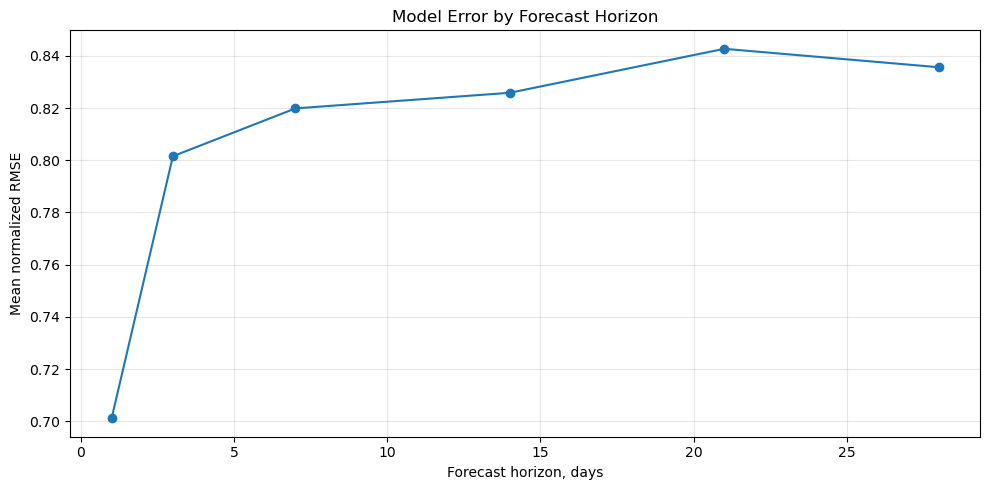

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    horizon_summary["horizon"],
    horizon_summary["NRMSE_mean"],
    marker="o",
)

plt.title("Model Error by Forecast Horizon")
plt.xlabel("Forecast horizon, days")
plt.ylabel("Mean normalized RMSE")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "model_error_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

Weather forecasting usually becomes harder as the horizon increases.

This horizon-by-horizon evaluation shows whether the model remains useful for short, medium, and longer forecast windows.

### 6.4 Per-Target Performance

In [16]:
final_model_candidate = "GradientBoosting"

per_target_28d = exp_28["target_results"][final_model_candidate].copy()

display(per_target_28d)

,target,MAE,RMSE,R2,target_std,target_range,NRMSE_by_std,NMAE_by_std
0,temperature_2m_max,3.462881,4.520840,0.767679,9.750947,52.8,0.463631,0.355133
1,precipitation_sum,2.717773,6.123858,-0.016181,4.943814,144.5,1.238691,0.549732
2,wind_speed_10m_max,4.538818,5.812168,0.111970,7.422179,53.9,0.783081,0.611521
3,relative_humidity_2m_mean,9.393804,11.688898,0.357436,15.015312,85.0,0.778465,0.625615
4,cloud_cover_mean,26.053194,30.720440,0.182354,33.600176,100.0,0.914294,0.775389


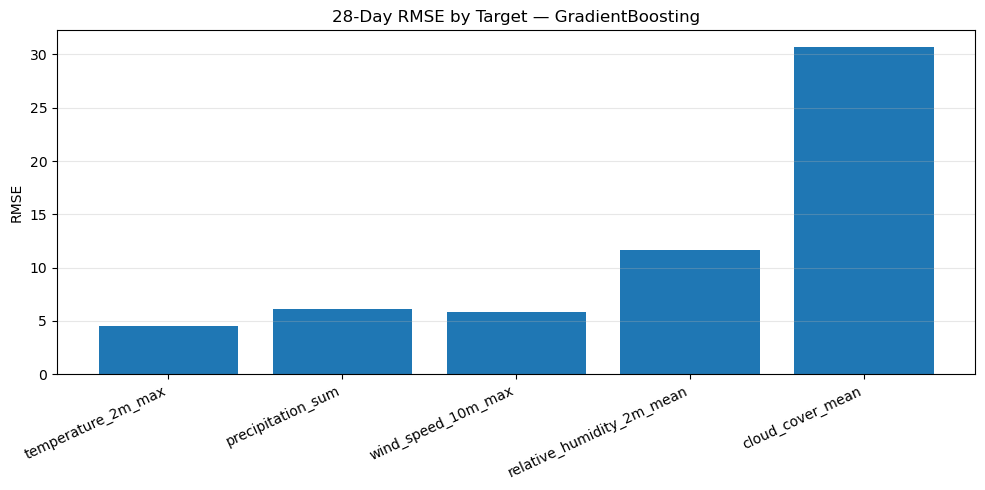

In [17]:
plt.figure(figsize=(10, 5))

plt.bar(
    per_target_28d["target"],
    per_target_28d["RMSE"],
)

plt.title(f"28-Day RMSE by Target — {final_model_candidate}")
plt.ylabel("RMSE")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "model_rmse_by_target_28d.png", dpi=150, bbox_inches="tight")
plt.show()

The per-target metrics show which weather variables are easier or harder to predict.

Temperature is expected to be easier because it has strong seasonal and location-based patterns.  
Precipitation and cloud cover are harder because they are irregular and event-driven.

### 6.5 City-Level Evaluation

In [18]:
def evaluate_by_city(
    test_df: pd.DataFrame,
    y_pred: np.ndarray,
    target_names: list[str],
) -> pd.DataFrame:
    """
    Evaluate model performance separately for each city.
    """

    rows = []

    pred_df = test_df[["city", "time", "target_time"]].copy()

    for i, target in enumerate(target_names):
        clean_target = target.replace("_target", "")
        pred_df[f"{clean_target}_actual"] = test_df[target].values
        pred_df[f"{clean_target}_pred"] = y_pred[:, i]

    for city in pred_df["city"].unique():
        city_df = pred_df[pred_df["city"] == city]

        for target in target_names:
            clean_target = target.replace("_target", "")

            actual = city_df[f"{clean_target}_actual"]
            pred = city_df[f"{clean_target}_pred"]

            rows.append({
                "city": city,
                "target": clean_target,
                "MAE": mean_absolute_error(actual, pred),
                "RMSE": np.sqrt(mean_squared_error(actual, pred)),
                "R2": r2_score(actual, pred),
            })

    return pd.DataFrame(rows)

In [19]:
final_preds_28 = exp_28["predictions"][final_model_candidate]

city_eval_28 = evaluate_by_city(
    test_df=exp_28["test_df"],
    y_pred=final_preds_28,
    target_names=horizon_target_cols,
)

display(city_eval_28)

,city,target,MAE,RMSE,R2
0,Baku,temperature_2m_max,3.269183,4.186378,0.788615
1,Baku,precipitation_sum,1.891745,5.340094,-0.031792
2,Baku,wind_speed_10m_max,7.200346,8.383535,-0.405345
3,Baku,relative_humidity_2m_mean,7.792497,9.764409,0.371197
4,Baku,cloud_cover_mean,25.189753,29.764477,0.258662
5,Gabala,temperature_2m_max,3.338584,4.315770,0.805028
6,Gabala,precipitation_sum,1.769943,3.676539,-0.037398
7,Gabala,wind_speed_10m_max,4.610101,5.948412,0.080253
8,Gabala,relative_humidity_2m_mean,8.530481,10.740522,0.568647
9,Gabala,cloud_cover_mean,24.660812,29.648273,0.163696


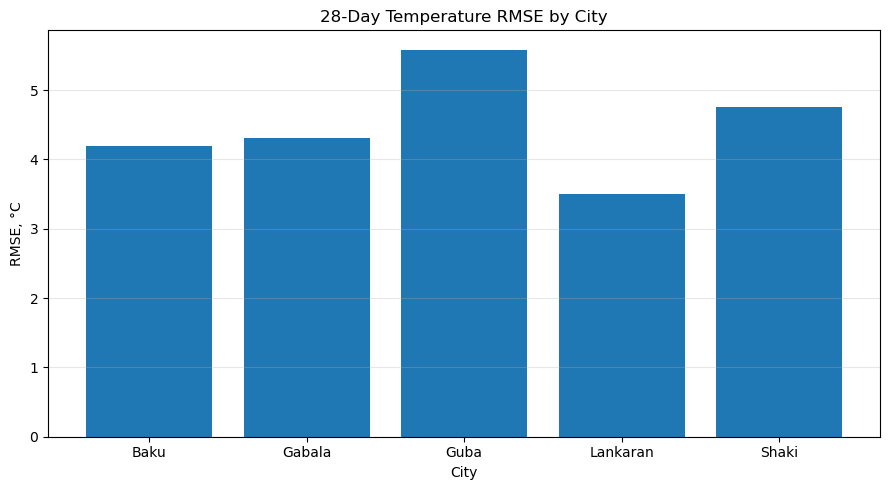

In [20]:
temp_city_eval = city_eval_28[
    city_eval_28["target"] == "temperature_2m_max"
].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    temp_city_eval["city"],
    temp_city_eval["RMSE"],
)

plt.title("28-Day Temperature RMSE by City")
plt.xlabel("City")
plt.ylabel("RMSE, °C")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "temperature_rmse_by_city_28d.png", dpi=150, bbox_inches="tight")
plt.show()

City-level evaluation is important because the five cities have different climate patterns.

A model can perform well on average but still be weaker for a specific city.  
This table helps identify where the system is more reliable and where further improvement is needed.

### 6.6 Prediction Intervals and Coverage

In [21]:
def time_train_calibration_test_split(
    supervised_df: pd.DataFrame,
    train_end: str,
    calibration_end: str,
):
    """
    Split supervised data into:
    - train
    - calibration
    - test

    Calibration is used to estimate prediction interval widths.
    """

    train_df = supervised_df[supervised_df["time"] < train_end].copy()

    calibration_df = supervised_df[
        (supervised_df["time"] >= train_end)
        & (supervised_df["time"] < calibration_end)
    ].copy()

    test_df = supervised_df[
        supervised_df["time"] >= calibration_end
    ].copy()

    return train_df, calibration_df, test_df

In [22]:
def fit_model_with_conformal_intervals(
    model_template,
    train_df: pd.DataFrame,
    calibration_df: pd.DataFrame,
    feature_cols: list[str],
    target_cols: list[str],
    alpha: float = 0.10,
):
    """
    Fit model and estimate conformal prediction interval widths.

    alpha=0.10 gives approximately 90% prediction intervals.
    """

    X_train = train_df[feature_cols]
    y_train = train_df[target_cols]

    X_cal = calibration_df[feature_cols]
    y_cal = calibration_df[target_cols]

    model = clone(model_template)
    model.fit(X_train, y_train)

    cal_pred = model.predict(X_cal)

    interval_widths = {}

    for i, target in enumerate(target_cols):
        residuals = np.abs(y_cal.iloc[:, i].values - cal_pred[:, i])
        q = np.quantile(residuals, 1 - alpha)
        interval_widths[target] = q

    return model, interval_widths

In [23]:
def predict_with_intervals(
    model,
    X: pd.DataFrame,
    target_cols: list[str],
    interval_widths: dict,
):
    """
    Generate point predictions with lower and upper prediction intervals.
    """

    preds = model.predict(X)

    rows = []

    for row_idx in range(len(X)):
        row = {}

        for i, target in enumerate(target_cols):
            clean_target = target.replace("_target", "")

            pred = preds[row_idx, i]
            width = interval_widths[target]

            lower = pred - width
            upper = pred + width

            if clean_target in [
                "precipitation_sum",
                "wind_speed_10m_max",
                "relative_humidity_2m_mean",
                "cloud_cover_mean",
            ]:
                lower = max(0, lower)

            if clean_target in [
                "relative_humidity_2m_mean",
                "cloud_cover_mean",
            ]:
                upper = min(100, upper)

            row[f"{clean_target}_pred"] = pred
            row[f"{clean_target}_lower"] = lower
            row[f"{clean_target}_upper"] = upper

        rows.append(row)

    return pd.DataFrame(rows)

In [24]:
def evaluate_interval_coverage(
    test_df: pd.DataFrame,
    interval_pred_df: pd.DataFrame,
    target_cols: list[str],
) -> pd.DataFrame:
    """
    Evaluate prediction interval coverage.

    For 90% intervals, coverage should be close to 0.90.
    """

    rows = []

    for target in target_cols:
        clean_target = target.replace("_target", "")

        actual = test_df[target].values
        lower = interval_pred_df[f"{clean_target}_lower"].values
        upper = interval_pred_df[f"{clean_target}_upper"].values

        covered = (actual >= lower) & (actual <= upper)
        width = upper - lower

        rows.append({
            "target": clean_target,
            "coverage": covered.mean(),
            "mean_interval_width": width.mean(),
            "median_interval_width": np.median(width),
        })

    return pd.DataFrame(rows)

In [25]:
supervised_28 = make_supervised(df, horizon=28)

train_ci_df, calibration_ci_df, test_ci_df = time_train_calibration_test_split(
    supervised_df=supervised_28,
    train_end="2024-01-01",
    calibration_end="2025-01-01",
)

print("Train:", train_ci_df["time"].min(), "→", train_ci_df["time"].max(), train_ci_df.shape)
print("Calibration:", calibration_ci_df["time"].min(), "→", calibration_ci_df["time"].max(), calibration_ci_df.shape)
print("Test:", test_ci_df["time"].min(), "→", test_ci_df["time"].max(), test_ci_df.shape)

Train: 2020-05-06 00:00:00 → 2023-12-31 00:00:00 (6675, 55)
Calibration: 2024-01-01 00:00:00 → 2024-12-31 00:00:00 (1830, 55)
Test: 2025-01-01 00:00:00 → 2026-04-01 00:00:00 (2280, 55)


In [26]:
conformal_model_28, interval_widths_28 = fit_model_with_conformal_intervals(
    model_template=models[final_model_candidate],
    train_df=train_ci_df,
    calibration_df=calibration_ci_df,
    feature_cols=horizon_feature_cols,
    target_cols=horizon_target_cols,
    alpha=0.10,
)

interval_widths_28

{'temperature_2m_max_target': np.float64(5.919458524801059),
 'precipitation_sum_target': np.float64(4.744248419328216),
 'wind_speed_10m_max_target': np.float64(8.792846587902483),
 'relative_humidity_2m_mean_target': np.float64(19.435185346620415),
 'cloud_cover_mean_target': np.float64(50.37074841546838)}

In [27]:
test_interval_preds_28 = predict_with_intervals(
    model=conformal_model_28,
    X=test_ci_df[horizon_feature_cols],
    target_cols=horizon_target_cols,
    interval_widths=interval_widths_28,
)

coverage_28 = evaluate_interval_coverage(
    test_df=test_ci_df,
    interval_pred_df=test_interval_preds_28,
    target_cols=horizon_target_cols,
)

display(coverage_28)

,target,coverage,mean_interval_width,median_interval_width
0,temperature_2m_max,0.838158,11.838917,11.838917
1,precipitation_sum,0.894737,6.396986,6.166420
2,wind_speed_10m_max,0.870614,17.585204,17.585693
3,relative_humidity_2m_mean,0.906579,38.703857,38.870371
4,cloud_cover_mean,0.919737,86.675372,87.362379


Prediction intervals are added because point forecasts are not enough for tourism planning.

For outdoor activity decisions, the platform should communicate uncertainty.  
For example, a temperature forecast of 24°C is more useful if we also know whether the likely range is 22–26°C or 15–32°C.

This notebook uses conformal prediction intervals.  
The model is trained on historical data, then a calibration period is used to estimate typical prediction errors.

Coverage shows how often the real value falls inside the interval.

## 7. Select Final Model

In [28]:
results_7_with_skill = add_skill_score(exp_7["overall_results"])
results_28_with_skill = add_skill_score(exp_28["overall_results"])

best_7d_name = results_7_with_skill.iloc[0]["model"]
best_28d_name = results_28_with_skill.iloc[0]["model"]

final_model_name = "GradientBoosting"

print("Best 7-day model:", best_7d_name)
print("Best 28-day model:", best_28d_name)
print("Final selected model:", final_model_name)

Best 7-day model: Ridge
Best 28-day model: GradientBoosting
Final selected model: GradientBoosting


The final model is selected based on the 28-day forecasting goal.

Even if another model performs slightly better on one horizon, Gradient Boosting is selected because:
- it performs strongly on the 28-day horizon,
- it handles nonlinear patterns,
- it supports feature importance,
- it is already used consistently in the production pipeline,
- it keeps the notebook aligned with `src.pipeline`.

The goal is not only to maximize one metric, but to keep the modeling approach stable, explainable, and compatible with the end-to-end pipeline.

## 8. Feature Importance Analysis

### 8.1 Tree-Based Feature Importance

In [29]:
def get_multioutput_feature_importance(
    model: MultiOutputRegressor,
    feature_names: list[str],
) -> pd.DataFrame:
    """
    Average feature importance across target-specific estimators.
    Works for tree-based models wrapped in MultiOutputRegressor.
    """

    importances = []

    for estimator in model.estimators_:
        if hasattr(estimator, "feature_importances_"):
            importances.append(estimator.feature_importances_)

    if not importances:
        raise ValueError("This model does not expose feature_importances_.")

    mean_importance = np.mean(importances, axis=0)

    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": mean_importance,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

In [30]:
df_sup_28 = make_supervised(df, horizon=28)

train_28 = df_sup_28[df_sup_28["time"] < split_date].copy()

X_train_28 = train_28[horizon_feature_cols]
y_train_28 = train_28[horizon_target_cols]

final_backtest_model = clone(models[final_model_name])
final_backtest_model.fit(X_train_28, y_train_28)

importance_28 = get_multioutput_feature_importance(
    model=final_backtest_model,
    feature_names=horizon_feature_cols,
)

display(importance_28.head(20))

,feature,importance
0,day_cos,0.307382
1,city_encoded,0.190318
2,target_day_cos,0.137319
3,wind_7d_avg,0.042939
4,humidity_14d_avg,0.029112
5,target_day_sin,0.027086
6,temperature_14d_avg,0.022080
7,target_day_of_month,0.018295
8,target_day_of_year,0.017336
9,day_sin,0.016821


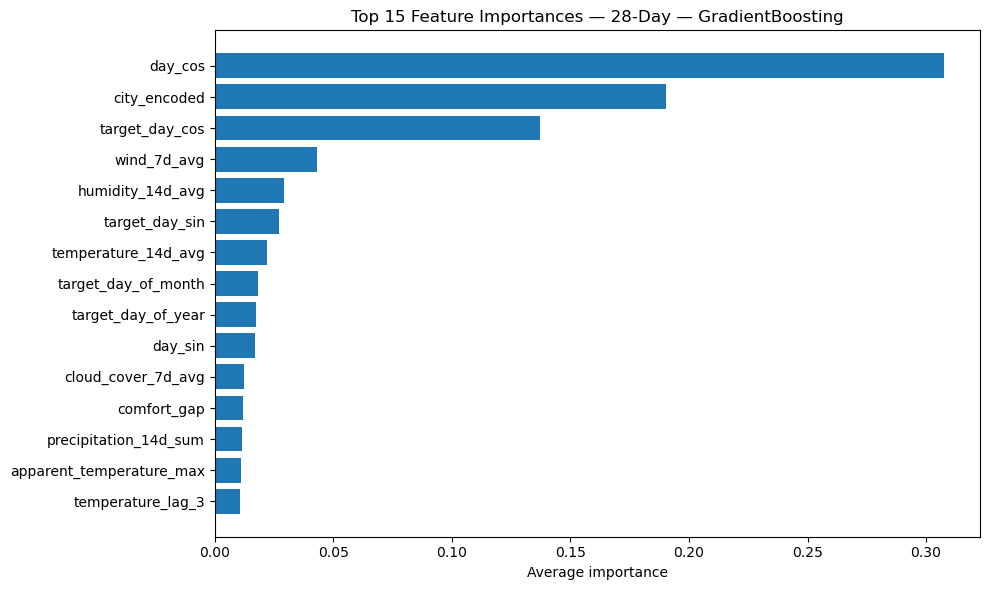

In [48]:
top_n = 15

plt.figure(figsize=(10, 6))

plt.barh(
    importance_28.head(top_n)["feature"][::-1],
    importance_28.head(top_n)["importance"][::-1],
)

plt.title(f"Top {top_n} Feature Importances — 28-Day — {final_model_name}")
plt.xlabel("Average importance")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "feature_importance_28d.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 Feature Group Ablation

In [32]:
feature_groups = {
    "calendar_current": [
        "month",
        "day_of_month",
        "day_sin",
        "day_cos",
    ],

    "calendar_target": [
        "target_month",
        "target_day_of_month",
        "target_day_of_year",
        "target_day_sin",
        "target_day_cos",
    ],

    "city": [
        "city_encoded",
    ],

    "comfort": [
        "apparent_temperature_max",
        "sunshine_duration",
        "comfort_gap",
        "sunshine_ratio",
    ],

    "lags": [
        "temperature_lag_1",
        "temperature_lag_3",
        "temperature_lag_7",
        "precipitation_lag_1",
        "precipitation_lag_3",
        "precipitation_lag_7",
        "wind_lag_1",
        "wind_lag_3",
        "humidity_lag_1",
        "humidity_lag_3",
    ],

    "rolling": [
        "temperature_3d_avg",
        "temperature_7d_avg",
        "temperature_14d_avg",
        "precipitation_3d_sum",
        "precipitation_7d_sum",
        "precipitation_14d_sum",
        "wind_3d_avg",
        "wind_7d_avg",
        "humidity_7d_avg",
        "humidity_14d_avg",
        "cloud_cover_7d_avg",
        "rainy_days_7d",
    ],

    "trends": [
        "temperature_trend_1d",
        "humidity_trend_1d",
        "wind_trend_1d",
        "precipitation_trend_1d",
    ],
}

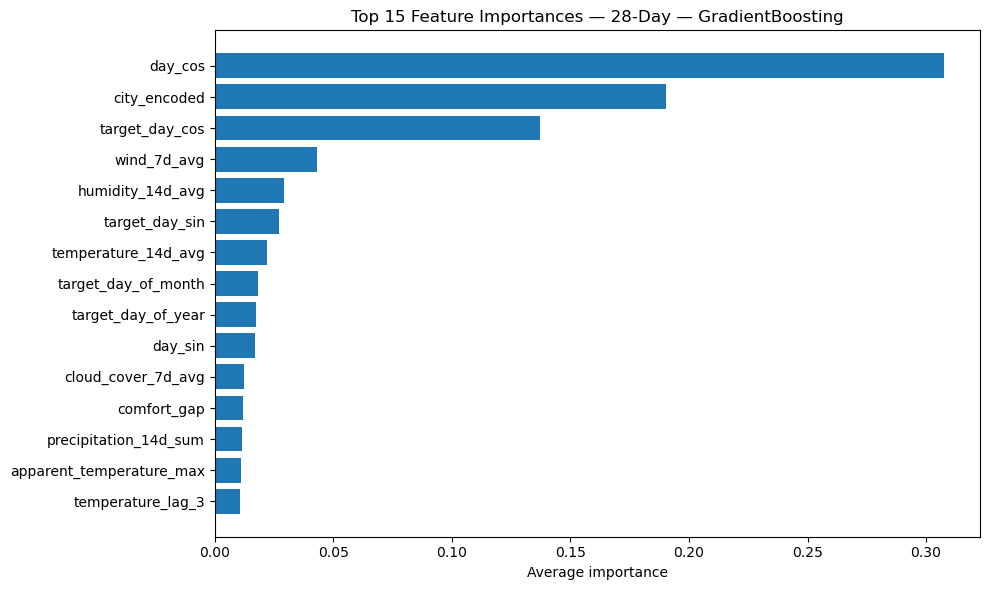

In [49]:
top_n = 15

plt.figure(figsize=(10, 6))

plt.barh(
    importance_28.head(top_n)["feature"][::-1],
    importance_28.head(top_n)["importance"][::-1],
)

plt.title(f"Top {top_n} Feature Importances — 28-Day — {final_model_name}")
plt.xlabel("Average importance")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "feature_importance_28d.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
def run_ablation_test(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    all_features: list[str],
    target_cols: list[str],
    model_template,
    feature_groups: dict,
):
    """
    Remove one feature group at a time and measure performance change.

    If removing a group increases error, the group is useful.
    If removing a group decreases error, the group may be noisy.
    """

    results = []

    X_train_full = train_df[all_features]
    y_train = train_df[target_cols]

    X_test_full = test_df[all_features]
    y_test = test_df[target_cols]

    baseline_model = clone(model_template)
    baseline_model.fit(X_train_full, y_train)
    baseline_pred = baseline_model.predict(X_test_full)

    baseline_eval = evaluate_multitarget_advanced(
        y_true=y_test,
        y_pred=baseline_pred,
        target_names=target_cols,
        y_train_reference=y_train,
    )

    baseline_nrmse = baseline_eval["NRMSE_by_std"].mean()

    results.append({
        "removed_group": "NONE_BASELINE",
        "features_used": len(all_features),
        "NRMSE_mean": baseline_nrmse,
        "delta_vs_baseline": 0.0,
    })

    for group_name, group_features in feature_groups.items():
        reduced_features = [
            col for col in all_features
            if col not in group_features
        ]

        model = clone(model_template)
        model.fit(train_df[reduced_features], y_train)

        pred = model.predict(test_df[reduced_features])

        eval_df = evaluate_multitarget_advanced(
            y_true=y_test,
            y_pred=pred,
            target_names=target_cols,
            y_train_reference=y_train,
        )

        nrmse = eval_df["NRMSE_by_std"].mean()

        results.append({
            "removed_group": group_name,
            "features_used": len(reduced_features),
            "NRMSE_mean": nrmse,
            "delta_vs_baseline": nrmse - baseline_nrmse,
        })

    return (
        pd.DataFrame(results)
        .sort_values("delta_vs_baseline", ascending=False)
        .reset_index(drop=True)
    )

In [34]:
ablation_28 = run_ablation_test(
    train_df=exp_28["train_df"],
    test_df=exp_28["test_df"],
    all_features=horizon_feature_cols,
    target_cols=horizon_target_cols,
    model_template=models[final_model_name],
    feature_groups=feature_groups,
)

display(ablation_28)

,removed_group,features_used,NRMSE_mean,delta_vs_baseline
0,city,39,0.847397,0.011764
1,calendar_current,36,0.837212,0.001580
2,calendar_target,35,0.836556,0.000924
3,comfort,36,0.835941,0.000308
4,trends,36,0.835823,0.000191
5,NONE_BASELINE,40,0.835632,0.000000
6,lags,30,0.833753,-0.001880
7,rolling,28,0.833575,-0.002057


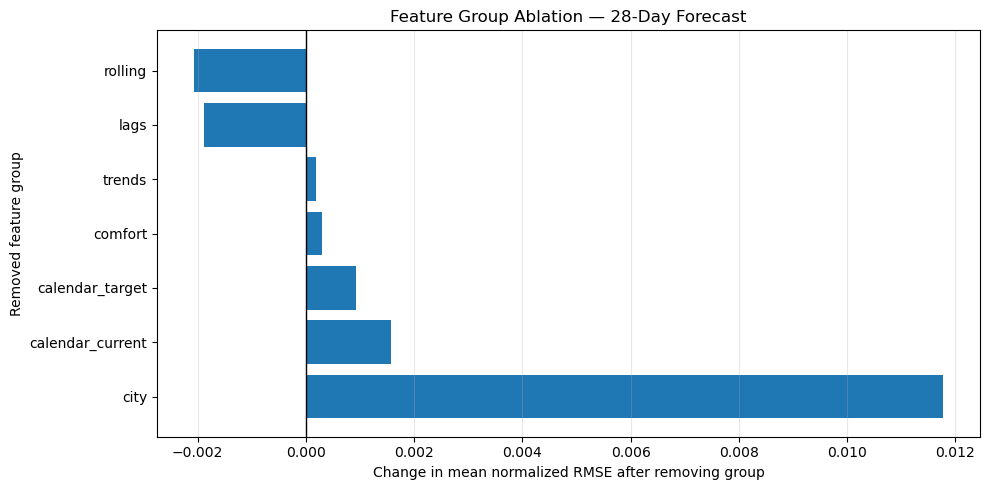

In [35]:
plot_df = ablation_28[
    ablation_28["removed_group"] != "NONE_BASELINE"
].copy()

plt.figure(figsize=(10, 5))

plt.barh(
    plot_df["removed_group"],
    plot_df["delta_vs_baseline"],
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Feature Group Ablation — 28-Day Forecast")
plt.xlabel("Change in mean normalized RMSE after removing group")
plt.ylabel("Removed feature group")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "feature_group_ablation_28d.png", dpi=150, bbox_inches="tight")
plt.show()

Feature importance shows which features the model uses, but it does not prove that a feature group improves validation performance.

For that reason, feature group ablation is added.

Interpretation:

- `delta_vs_baseline > 0`: removing this group made the model worse, so the group is useful.
- `delta_vs_baseline < 0`: removing this group improved the model, so the group may be noisy.

This is especially useful for checking whether comfort-related features such as `apparent_temperature_max` are helping or creating noise.

## 9. Prepare Latest Forecast Base

The final forecast uses a hybrid strategy.

First, we use the 7-day Open-Meteo forecast directly. Then we combine historical data with this 7-day forecast to create the latest feature rows for each city. These rows become the starting point for ML predictions for days 8–28.

### 9.1 Load Forecast Data

In [36]:
forecast_df = run_query("SELECT * FROM raw.forecast").copy()

forecast_df["time"] = pd.to_datetime(forecast_df["time"])
forecast_df = forecast_df.sort_values(["city", "time"]).reset_index(drop=True)

print("Forecast shape:", forecast_df.shape)
print("Forecast date range:", forecast_df["time"].min(), "→", forecast_df["time"].max())

display(forecast_df.head())

Forecast shape: (35, 9)
Forecast date range: 2026-04-30 00:00:00 → 2026-05-06 00:00:00


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city
0,2026-04-30,15.9,0.0,26.1,70,68,14.3,38648.35,Baku
1,2026-05-01,16.7,0.0,32.4,83,59,13.2,44313.31,Baku
2,2026-05-02,18.6,0.0,29.4,84,74,17.9,31755.56,Baku
3,2026-05-03,13.9,0.0,28.2,80,82,10.7,18486.48,Baku
4,2026-05-04,17.5,0.0,29.7,85,70,15.6,45356.23,Baku


### 9.2 Combine Historical and Forecast Data

In [37]:
historical_raw = run_query("SELECT * FROM raw.historical").copy()
forecast_raw = run_query("SELECT * FROM raw.forecast").copy()

historical_raw["time"] = pd.to_datetime(historical_raw["time"])
forecast_raw["time"] = pd.to_datetime(forecast_raw["time"])

combined_for_future = pd.concat(
    [historical_raw, forecast_raw],
    ignore_index=True,
)

combined_for_future = (
    combined_for_future
    .sort_values(["city", "time"])
    .drop_duplicates(subset=["city", "time"], keep="last")
    .reset_index(drop=True)
)

future_feature_df, _ = build_features(combined_for_future)

latest_origin = (
    future_feature_df
    .sort_values(["city", "time"])
    .groupby("city")
    .tail(1)
    .reset_index(drop=True)
)

display(latest_origin[["city", "time"]])

,city,time
0,Baku,2026-05-06
1,Gabala,2026-05-06
2,Guba,2026-05-06
3,Lankaran,2026-05-06
4,Shaki,2026-05-06


The ML part of the forecast starts after the 7-day API forecast.

To create the latest origin row for ML prediction, historical data is combined with the latest API forecast.  
This allows lag and rolling features to include the most recent available information before predicting days 8–28.

## 10. Build Final 28-Day Hybrid Forecast

### 10.1 — Prepare API forecast

In [38]:
def prepare_api_forecast_output(forecast_df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare Open-Meteo forecast as days 1-7 of the final 28-day forecast.
    """

    api_part = forecast_df.copy()
    api_part = api_part.sort_values(["city", "time"]).reset_index(drop=True)

    api_part["origin_time"] = (
        api_part.groupby("city")["time"].transform("min")
        - pd.Timedelta(days=1)
    )

    api_part["forecast_horizon"] = api_part.groupby("city").cumcount() + 1
    api_part["target_time"] = api_part["time"]
    api_part["source"] = "api_forecast"

    output_cols = [
        "city",
        "origin_time",
        "forecast_horizon",
        "target_time",
        "source",
    ] + target_cols

    return api_part[output_cols]

### 10.2 — Train direct horizon models

In [39]:
def train_direct_horizon_models(
    df_input: pd.DataFrame,
    horizons: list[int],
    model_name: str,
) -> dict[int, MultiOutputRegressor]:
    """
    Train one model per horizon.

    Horizon 1 after the API forecast corresponds to final forecast day 8.
    Horizon 21 after the API forecast corresponds to final forecast day 28.
    """

    trained_models = {}

    for horizon in horizons:
        print(f"Training {model_name} for ML horizon={horizon}...")

        supervised_df = make_supervised(df_input, horizon=horizon)

        X_train = supervised_df[horizon_feature_cols]
        y_train = supervised_df[horizon_target_cols]

        model = clone(models[model_name])
        model.fit(X_train, y_train)

        trained_models[horizon] = model

    return trained_models

### 10.3 — Predict ml days after API

In [40]:
def predict_ml_days_after_api(
    latest_origin_df: pd.DataFrame,
    training_df: pd.DataFrame,
    model_name: str,
    ml_days: int = 21,
) -> pd.DataFrame:
    """
    Predict days 8-28 of the final forecast.

    API covers days 1-7.
    ML model covers the remaining 21 days.
    """

    horizons = list(range(1, ml_days + 1))

    direct_models = train_direct_horizon_models(
        df_input=training_df,
        horizons=horizons,
        model_name=model_name,
    )

    rows = []

    for _, origin_row in latest_origin_df.iterrows():
        city = origin_row["city"]
        origin_time = pd.to_datetime(origin_row["time"])

        for horizon in horizons:
            target_time = origin_time + pd.Timedelta(days=horizon)

            row = origin_row.copy()
            row["target_time"] = target_time
            row["target_month"] = target_time.month
            row["target_day_of_month"] = target_time.day
            row["target_day_of_year"] = target_time.dayofyear
            row["target_day_sin"] = np.sin(
                2 * np.pi * target_time.dayofyear / 365.25
            )
            row["target_day_cos"] = np.cos(
                2 * np.pi * target_time.dayofyear / 365.25
            )

            X_future = pd.DataFrame([row])[horizon_feature_cols]
            pred = direct_models[horizon].predict(X_future)[0]

            result = {
                "city": city,
                "origin_time": origin_time,
                "forecast_horizon": horizon + 7,
                "target_time": target_time,
                "source": "ml_model",
            }

            for i, target in enumerate(target_cols):
                result[target] = pred[i]

            rows.append(result)

    return pd.DataFrame(rows)

### 10.4 — Build final forecast

In [41]:
api_7d = prepare_api_forecast_output(forecast_df)

ml_21d = predict_ml_days_after_api(
    latest_origin_df=latest_origin,
    training_df=df,
    model_name=final_model_name,
    ml_days=21,
)

final_28d_forecast = (
    pd.concat([api_7d, ml_21d], ignore_index=True)
    .sort_values(["city", "target_time"])
    .reset_index(drop=True)
)

print("Final forecast date range:")
print(
    final_28d_forecast["target_time"].min(),
    "→",
    final_28d_forecast["target_time"].max(),
)

print("\nRows by city and source:")
display(
    final_28d_forecast
    .groupby(["city", "source"])
    .size()
    .reset_index(name="rows")
)

display(final_28d_forecast.head(35))

Training GradientBoosting for ML horizon=1...
Training GradientBoosting for ML horizon=2...
Training GradientBoosting for ML horizon=3...
Training GradientBoosting for ML horizon=4...
Training GradientBoosting for ML horizon=5...
Training GradientBoosting for ML horizon=6...
Training GradientBoosting for ML horizon=7...
Training GradientBoosting for ML horizon=8...
Training GradientBoosting for ML horizon=9...
Training GradientBoosting for ML horizon=10...
Training GradientBoosting for ML horizon=11...
Training GradientBoosting for ML horizon=12...
Training GradientBoosting for ML horizon=13...
Training GradientBoosting for ML horizon=14...
Training GradientBoosting for ML horizon=15...
Training GradientBoosting for ML horizon=16...
Training GradientBoosting for ML horizon=17...
Training GradientBoosting for ML horizon=18...
Training GradientBoosting for ML horizon=19...
Training GradientBoosting for ML horizon=20...
Training GradientBoosting for ML horizon=21...
Final forecast date ra

,city,source,rows
0,Baku,api_forecast,7
1,Baku,ml_model,21
2,Gabala,api_forecast,7
3,Gabala,ml_model,21
4,Guba,api_forecast,7
5,Guba,ml_model,21
6,Lankaran,api_forecast,7
7,Lankaran,ml_model,21
8,Shaki,api_forecast,7
9,Shaki,ml_model,21


,city,origin_time,forecast_horizon,target_time,source,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean
0,Baku,2026-04-29,1,2026-04-30,api_forecast,15.900000,0.000000,26.100000,70.000000,68.000000
1,Baku,2026-04-29,2,2026-05-01,api_forecast,16.700000,0.000000,32.400000,83.000000,59.000000
2,Baku,2026-04-29,3,2026-05-02,api_forecast,18.600000,0.000000,29.400000,84.000000,74.000000
3,Baku,2026-04-29,4,2026-05-03,api_forecast,13.900000,0.000000,28.200000,80.000000,82.000000
4,Baku,2026-04-29,5,2026-05-04,api_forecast,17.500000,0.000000,29.700000,85.000000,70.000000
5,Baku,2026-04-29,6,2026-05-05,api_forecast,19.700000,0.000000,25.400000,78.000000,68.000000
6,Baku,2026-04-29,7,2026-05-06,api_forecast,18.000000,0.000000,26.700000,75.000000,71.000000
7,Baku,2026-05-06,8,2026-05-07,ml_model,18.952488,1.006361,25.684269,74.555497,52.050364
8,Baku,2026-05-06,9,2026-05-08,ml_model,18.984226,0.968304,26.377488,76.677415,58.444950
9,Baku,2026-05-06,10,2026-05-09,ml_model,18.618464,1.605394,25.038844,75.178117,56.947301


### 10.5 Visualize Final Forecast

In [42]:
def plot_final_forecast(
    forecast_df: pd.DataFrame,
    city: str,
    target: str,
) -> None:
    """
    Plot final 28-day hybrid forecast for one city and one target.
    """

    city_df = (
        forecast_df[forecast_df["city"] == city]
        .sort_values("target_time")
        .copy()
    )

    api_part = city_df[city_df["source"] == "api_forecast"]
    ml_part = city_df[city_df["source"] == "ml_model"]

    plt.figure(figsize=(12, 5))

    plt.plot(
        api_part["target_time"],
        api_part[target],
        marker="o",
        label="API forecast",
    )

    plt.plot(
        ml_part["target_time"],
        ml_part[target],
        marker="o",
        linestyle="--",
        label="ML forecast",
    )

    plt.title(f"Final 28-Day Forecast — {city} — {target}")
    plt.xlabel("Date")
    plt.ylabel(target)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    file_name = f"final_28d_forecast_{city.lower()}_{target}.png"
    plt.savefig(FIGURES_DIR / file_name, dpi=150, bbox_inches="tight")

    plt.show()

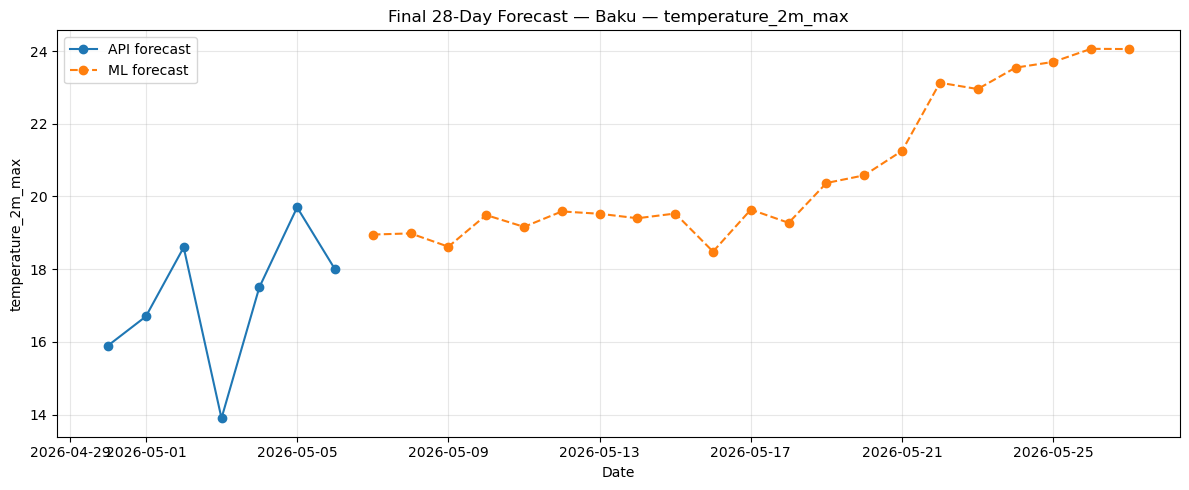

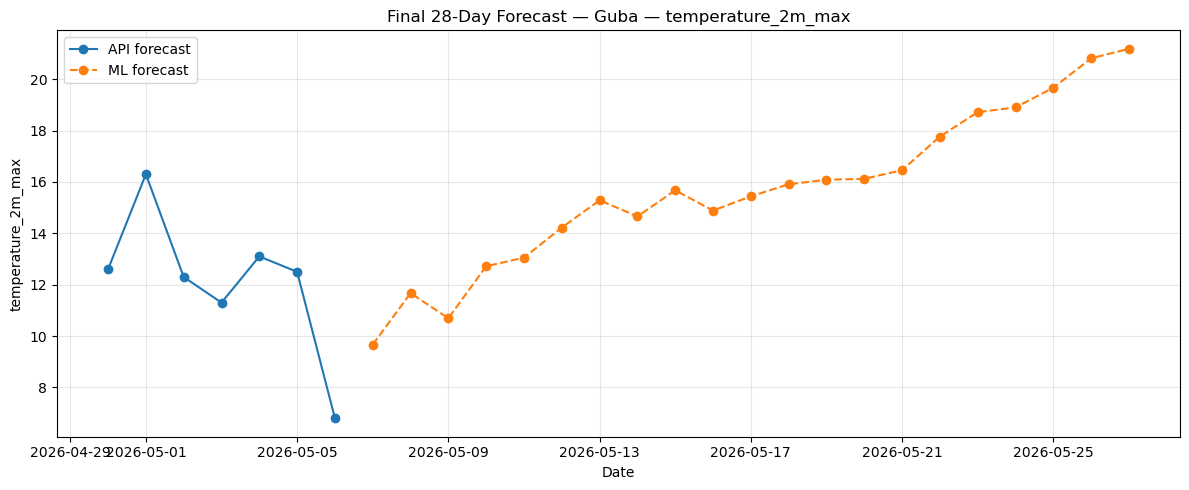

In [43]:
plot_final_forecast(
    forecast_df=final_28d_forecast,
    city="Baku",
    target="temperature_2m_max",
)

plot_final_forecast(
    forecast_df=final_28d_forecast,
    city="Guba",
    target="temperature_2m_max",
)

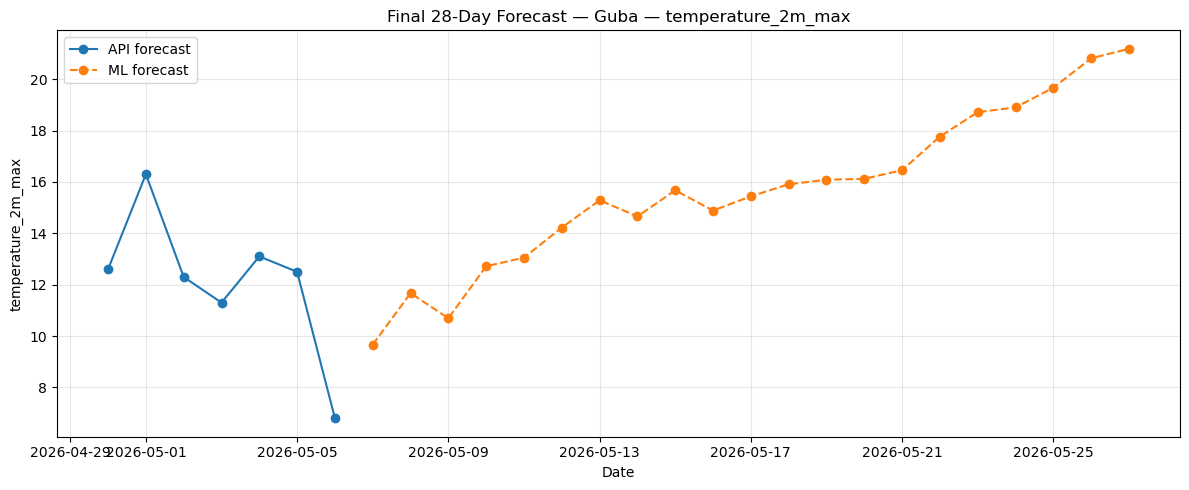

In [50]:
plot_final_forecast(
    forecast_df=final_28d_forecast,
    city="Guba",
    target="temperature_2m_max",
)

The final forecast is hybrid.

Days 1–7 come from the Open-Meteo Forecast API.  
Days 8–28 are predicted by the ML model.

This design does not try to replace the short-range API forecast.  
Instead, the ML model extends the forecast window for tourism planning.

## 11. Save Forecast Output

In [44]:
with get_connection() as conn:
    conn.execute("CREATE SCHEMA IF NOT EXISTS analytics;")
    conn.register("final_28d_forecast_view", final_28d_forecast)

    conn.execute("""
        CREATE OR REPLACE TABLE analytics.final_28d_forecast AS
        SELECT *
        FROM final_28d_forecast_view;
    """)

print("analytics.final_28d_forecast table created.")

analytics.final_28d_forecast table created.


### 11.1 Verify Saved Forecast

In [45]:
forecast_summary = run_query("""
SELECT
    MIN(target_time) AS min_date,
    MAX(target_time) AS max_date,
    COUNT(*) AS rows
FROM analytics.final_28d_forecast
""")

display(forecast_summary)

,min_date,max_date,rows
0,2026-04-30,2026-05-27,140


In [46]:
source_summary = run_query("""
SELECT
    city,
    source,
    COUNT(*) AS rows
FROM analytics.final_28d_forecast
GROUP BY city, source
ORDER BY city, source
""")

display(source_summary)

,city,source,rows
0,Baku,api_forecast,7
1,Baku,ml_model,21
2,Gabala,api_forecast,7
3,Gabala,ml_model,21
4,Guba,api_forecast,7
5,Guba,ml_model,21
6,Lankaran,api_forecast,7
7,Lankaran,ml_model,21
8,Shaki,api_forecast,7
9,Shaki,ml_model,21


In [47]:
expected_rows = 5 * 28

actual_rows = forecast_summary["rows"].iloc[0]

print("Expected rows:", expected_rows)
print("Actual rows:", actual_rows)

assert actual_rows == expected_rows, "Final forecast row count is incorrect."

Expected rows: 140
Actual rows: 140


The final table should contain:

5 cities × 28 forecast days = 140 rows

For each city:
- 7 rows from API forecast
- 21 rows from ML model

## Modeling Summary

This notebook trained and evaluated multi-output regression models for medium-range weather forecasting.

The final system uses a hybrid strategy:

- Days 1–7 are taken from the Open-Meteo Forecast API.
- Days 8–28 are predicted using direct horizon ML models.

The hybrid approach is used because short-range API forecasts are likely to be more reliable than a simple historical ML model for the first week.  
The ML model is used to extend the forecast window and support tourism planning beyond the API forecast horizon.

The final model is Gradient Boosting wrapped in `MultiOutputRegressor`.

The model predicts five weather targets:

- maximum temperature,
- precipitation,
- wind speed,
- relative humidity,
- cloud cover.

The evaluation includes:

- time-based backtesting,
- comparison against Dummy and linear baselines,
- per-target metrics,
- normalized metrics,
- skill score against Dummy baseline,
- horizon-by-horizon evaluation,
- city-level evaluation,
- feature importance,
- feature group ablation,
- prediction interval coverage.

The results show that temperature is the most predictable target because it has strong seasonal and location-based patterns.  
Precipitation and cloud cover are harder because they are irregular and event-driven.

For tourism planning, the model is useful not only as a precise weather predictor, but as a structured medium-range risk signal.  
It can support decisions such as whether to plan hiking, outdoor tours, indoor activities, or lower-risk countryside activities.

Future improvements:

- add prediction intervals to the saved final forecast table,
- evaluate activity-specific risk thresholds,
- convert weather variables into activity suitability scores,
- test whether comfort-related features should be removed,
- tune model hyperparameters,
- evaluate separate models for precipitation classification and regression.